# Exploratory Data Analysis (EDA) - Merged Listings Dataset

This notebook explores the uncleaned merged dataset at `data/processed/main/merged.csv`.

## Goals
- Understand dataset size, schema, and data quality.
- Inspect missing values, duplicates, and type issues.
- Visualize numeric distributions with histograms.
- Analyze feature relationships using correlation heatmap and scatterplots.
- Generate practical findings to guide cleaning and modeling.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
RANDOM_STATE = 42

In [2]:
candidate_paths = [
    Path('data/processed/main/merged.csv'),
    Path('../data/processed/main/merged.csv'),
    Path.cwd() / 'data/processed/main/merged.csv',
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError('Could not locate merged.csv in expected locations.')

df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path.resolve()}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

df.head()

Loaded: C:\Users\RUSHIKESH\Downloads\Dataset New\data\processed\main\merged.csv
Shape: 47,956 rows x 67 columns


C:\Users\RUSHIKESH\AppData\Local\Temp\ipykernel_17480\3122665815.py:16: DtypeWarning: Columns (0: superhost) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,listing_id,listing_name,listing_type,room_type,cover_photo_url,photos_count,host_id,host_name,cohost_ids,cohost_names,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,amenities,instant_book,professional_management,min_nights,cancellation_policy,currency,cleaning_fee,extra_guest_fee,num_reviews,rating_overall,rating_accuracy,rating_checkin,rating_cleanliness,rating_communication,rating_location,rating_value,ttm_revenue,ttm_revenue_native,ttm_avg_rate,ttm_avg_rate_native,ttm_occupancy,ttm_adjusted_occupancy,ttm_revpar,ttm_revpar_native,ttm_adjusted_revpar,ttm_adjusted_revpar_native,ttm_reserved_days,ttm_blocked_days,ttm_available_days,ttm_total_days,l90d_revenue,l90d_revenue_native,l90d_avg_rate,l90d_avg_rate_native,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,city,country,country_code,geographic_zone,distance_from_city_center
0,1754773.0,Centrally located in Accra with Chocolates to go!,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/ec7fdf2a-0...,34.0,9220860.0,Yaaba,NaN,NaN,True,5.5733,-0.1960,2.0,1.0,1.0,1.5,False,"TV,Cable TV,Wifi,Air conditioning,Kitchen,Free...",NaN,False,2.0,Moderate,GHS,0.0,0.0,71.0,4.87,4.8,4.8,4.9,4.9,4.9,4.8,6948.0,87855.0,41.9,498.8,0.452,0.630,19.0,240.7,26.5,335.3,165.0,103.0,200.0,365.0,1753.0,17971.0,39.0,400.2,0.500,0.763,19.5,199.7,29.7,304.6,45.0,31.0,45.0,90.0,Accra,Ghana,GH,Africa,1.924028
1,5059526.0,NEW! Luxury Studio at Embassy Gardens,Entire rental unit,entire_home,https://a0.muscache.com/im/pictures/a1c70987-6...,14.0,26125588.0,Alex,NaN,NaN,False,5.5860,-0.1673,2.0,NaN,NaN,1.0,False,"TV,Wifi,Air conditioning,Pool,Kitchen,Free par...",True,False,4.0,Moderate,GHS,50.0,0.0,55.0,4.60,4.8,4.7,4.5,4.6,4.9,4.6,6428.0,73122.0,67.7,792.1,0.238,0.282,16.1,184.9,19.0,218.4,87.0,56.0,278.0,365.0,1391.0,14249.0,73.3,750.4,0.189,0.000,14.3,146.9,0.0,0.0,17.0,0.0,73.0,90.0,Accra,Ghana,GH,Africa,4.673764
2,5296203.0,Studio Apt. in the center of Osu,Entire bungalow,entire_home,https://a0.muscache.com/im/pictures/68216885/b...,10.0,27429560.0,Linda,NaN,NaN,True,5.5610,-0.1856,2.0,1.0,1.0,1.0,False,"Hot water,TV,Air conditioning,Wifi,Kitchen,Dis...",NaN,False,5.0,Moderate,GHS,20.0,10.0,21.0,4.90,5.0,5.0,4.8,5.0,5.0,4.9,2533.0,26171.0,53.3,633.1,0.126,0.157,6.8,70.6,8.5,87.9,46.0,72.0,319.0,365.0,641.0,6564.0,48.9,501.0,0.144,0.271,6.9,70.7,12.9,132.5,13.0,42.0,77.0,90.0,Accra,Ghana,GH,Africa,1.367708
3,5385757.0,Oasis in Accra Central Osu Black Star Square,Private room in rental unit,private_room,https://a0.muscache.com/im/pictures/miso/Hosti...,14.0,14499704.0,Kobina,NaN,NaN,True,5.5534,-0.1795,NaN,NaN,1.0,0.0,False,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",NaN,False,2.0,Moderate,GHS,10.0,20.0,59.0,4.92,4.9,5.0,4.8,5.0,4.8,4.9,1719.0,17611.0,66.9,799.7,0.071,0.093,4.7,47.7,6.1,62.2,26.0,85.0,339.0,365.0,971.0,9948.0,63.8,653.1,0.167,0.000,10.7,109.4,0.0,0.0,15.0,0.0,75.0,90.0,Accra,Ghana,GH,Africa,1.947619
4,6531925.0,Oasis Garden - Researchers' Home(1 out of 6 ro...,Private room in home,private_room,https://a0.muscache.com/im/pictures/d3d5201d-5...,13.0,34168361.0,Gladys & Gidi,NaN,NaN,True,5.6235,-0.1790,NaN,NaN,1.0,0.0,False,"Hair dryer,Shampoo,Hot water,Shower gel,Washer...",NaN,False,3.0,Moderate,GHS,25.0,18.0,107.0,4.83,4.9,4.9,4.9,4.9,4.6,4.8,1423.0,18280.0,47.5,561.5,0.082,0.000,3.8,48.7,0.0,0.0,30.0,0.0,335.0,365.0,668.0,6842.0,45.3,464.2,0.156,0.000,7.1,73.2,0.0,0.0,14.0,0.0,76.0,90.0,Accra,Ghana,GH,Africa,7.760514


In [3]:
print('DataFrame info:')
print('-' * 80)
df.info()

print('\nBasic checks:')
print('-' * 80)
print(f'Duplicated rows: {df.duplicated().sum():,}')
print(f'Total missing cells: {df.isna().sum().sum():,}')
print(f'Rows with at least one missing value: {df.isna().any(axis=1).sum():,}')

missing_pct_by_row = (df.isna().mean(axis=1) * 100)
print(f'Median missing % per row: {missing_pct_by_row.median():.2f}%')
print(f'95th percentile missing % per row: {missing_pct_by_row.quantile(0.95):.2f}%')

DataFrame info:
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 47956 entries, 0 to 47955
Data columns (total 67 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   47955 non-null  float64
 1   listing_name                 47953 non-null  str    
 2   listing_type                 47955 non-null  str    
 3   room_type                    47955 non-null  str    
 4   cover_photo_url              47729 non-null  str    
 5   photos_count                 47729 non-null  float64
 6   host_id                      47955 non-null  float64
 7   host_name                    47577 non-null  str    
 8   cohost_ids                   11052 non-null  str    
 9   cohost_names                 11052 non-null  str    
 10  superhost                    47955 non-null  object 
 11  latitude                     47955 non-null  f

## Missingness and Data Quality Checks

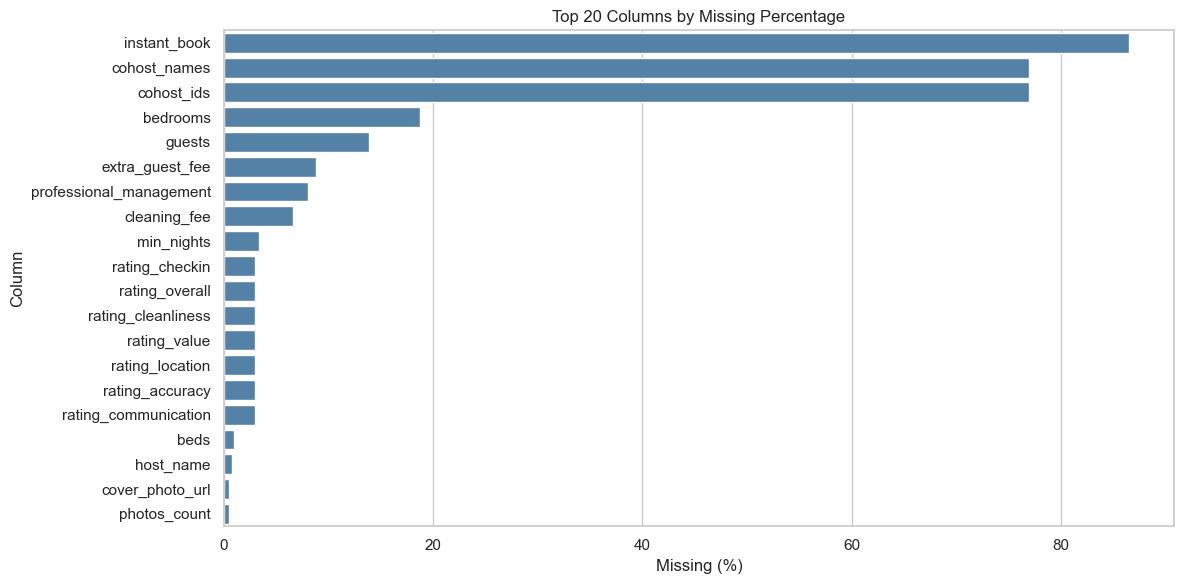

In [11]:
missing_summary = (
    df.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

missing_summary.head(20)

plt.figure(figsize=(12, 6))
plot_missing = missing_summary[missing_summary['missing_count'] > 0].head(20)
if not plot_missing.empty:
    sns.barplot(
        data=plot_missing.reset_index(),
        x='missing_pct',
        y='index',
        color='steelblue'
    )
    plt.title('Top 20 Columns by Missing Percentage')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
else:
    plt.text(0.5, 0.5, 'No missing values found', ha='center', va='center')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Build a plotting copy with gentle type coercion.
df_plot = df.copy()
converted_to_numeric = []
converted_to_bool = []

for col in df_plot.columns:
    series = df_plot[col]
    if series.dtype != 'object':
        continue

    non_null = series.dropna().astype(str).str.strip()
    if non_null.empty:
        continue

    upper_values = set(non_null.str.upper().unique())
    if upper_values.issubset({'TRUE', 'FALSE'}):
        mapped = series.astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False})
        mapped[series.isna()] = np.nan
        df_plot[col] = mapped
        converted_to_bool.append(col)
        continue

    numeric_candidate = pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )
    # Convert only when most values are valid numbers to avoid corrupting text fields.
    if numeric_candidate.notna().mean() >= 0.85:
        df_plot[col] = numeric_candidate
        converted_to_numeric.append(col)

print(f'Converted to numeric for EDA: {len(converted_to_numeric)} columns')
print(converted_to_numeric[:20])
print(f'Converted to boolean for EDA: {len(converted_to_bool)} columns')
print(converted_to_bool)

df_plot.select_dtypes(include='number').describe().T.head(15)

Converted to numeric for EDA: 0 columns
[]
Converted to boolean for EDA: 4 columns
['superhost', 'registration', 'instant_book', 'professional_management']


,count,mean,std,min,25%,50%,75%,max
listing_id,47955.0,7.035208e+16,2.463257e+17,6.0000,3.304204e+06,1.404276e+07,2.932606e+07,1.340000e+18
photos_count,47729.0,2.992753e+01,2.126356e+01,0.0000,1.600000e+01,2.500000e+01,3.700000e+01,4.930000e+02
host_id,47955.0,9.505075e+07,1.348172e+08,29.0000,7.111302e+06,3.388972e+07,1.263198e+08,7.374132e+08
latitude,47955.0,2.145174e+01,2.673440e+01,-45.0767,6.214200e+00,3.040900e+01,4.104980e+01,5.940720e+01
longitude,47955.0,-5.454582e-01,7.352662e+01,-157.8614,-7.124845e+01,1.031500e+01,3.262280e+01,1.748477e+02
guests,41308.0,4.311756e+00,2.673035e+00,1.0000,2.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01
bedrooms,38981.0,1.897540e+00,1.254062e+00,0.0000,1.000000e+00,2.000000e+00,2.000000e+00,4.100000e+01
beds,47473.0,2.483833e+00,2.048452e+00,0.0000,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+01
baths,47919.0,1.341065e+00,1.135050e+00,0.0000,1.000000e+00,1.000000e+00,2.000000e+00,3.800000e+01
min_nights,46358.0,6.948229e+00,3.538020e+01,1.0000,1.000000e+00,2.000000e+00,3.000000e+00,9.990000e+02


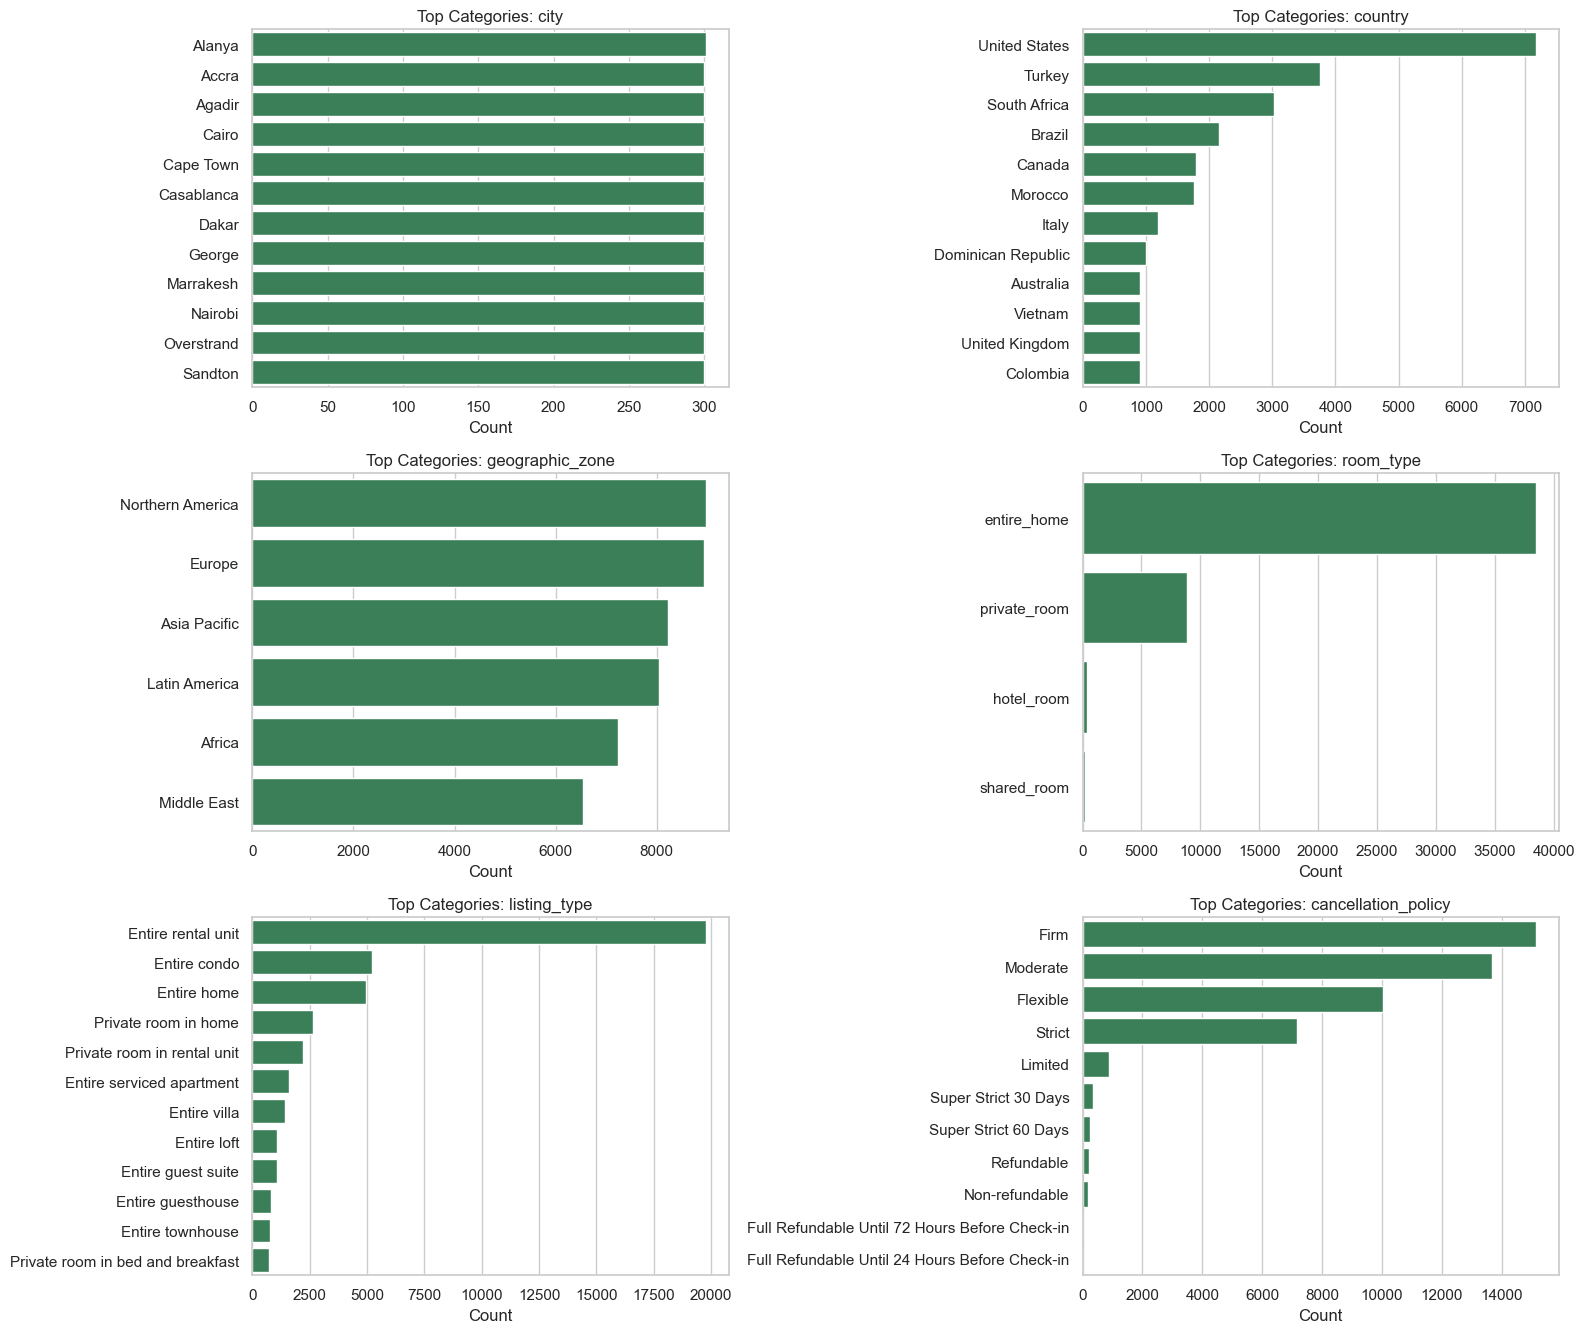


Top values for city:


,count
city,
Alanya,301
Accra,300
Agadir,300
Cairo,300
Cape Town,300
Casablanca,300
Dakar,300
George,300
Marrakesh,300



Top values for country:


,count
country,
United States,7174
Turkey,3761
South Africa,3024
Brazil,2165
Canada,1798
Morocco,1764
Italy,1200
Dominican Republic,997
Australia,900



Top values for geographic_zone:


...

,count
room_type,
entire_home,38510
private_room,8830
hotel_room,414
shared_room,201
NaN,1



Top values for listing_type:


,count
listing_type,
Entire rental unit,19773
Entire condo,5201
Entire home,4949
Private room in home,2664
Private room in rental unit,2192
Entire serviced apartment,1606
Entire villa,1410
Entire loft,1075
Entire guest suite,1068



Top values for cancellation_policy:


,count
cancellation_policy,
Firm,15154
Moderate,13691
Flexible,10027
Strict,7166
Limited,878
Super Strict 30 Days,345
Super Strict 60 Days,260
Refundable,215
Non-refundable,182


In [12]:
categorical_focus = [
    col for col in ['city', 'country', 'geographic_zone', 'room_type', 'listing_type', 'cancellation_policy']
    if col in df_plot.columns
]

if categorical_focus:
    n_cols = 2
    n_rows = int(np.ceil(len(categorical_focus) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, categorical_focus):
        top_counts = df_plot[col].astype(str).value_counts(dropna=False).head(12)
        sns.barplot(
            x=top_counts.values,
            y=top_counts.index,
            ax=ax,
            color='seagreen'
        )
        ax.set_title(f'Top Categories: {col}')
        ax.set_xlabel('Count')
        ax.set_ylabel('')

    for ax in axes[len(categorical_focus):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

for col in categorical_focus:
    print(f'\nTop values for {col}:')
    display(df_plot[col].value_counts(dropna=False).head(10).to_frame('count'))

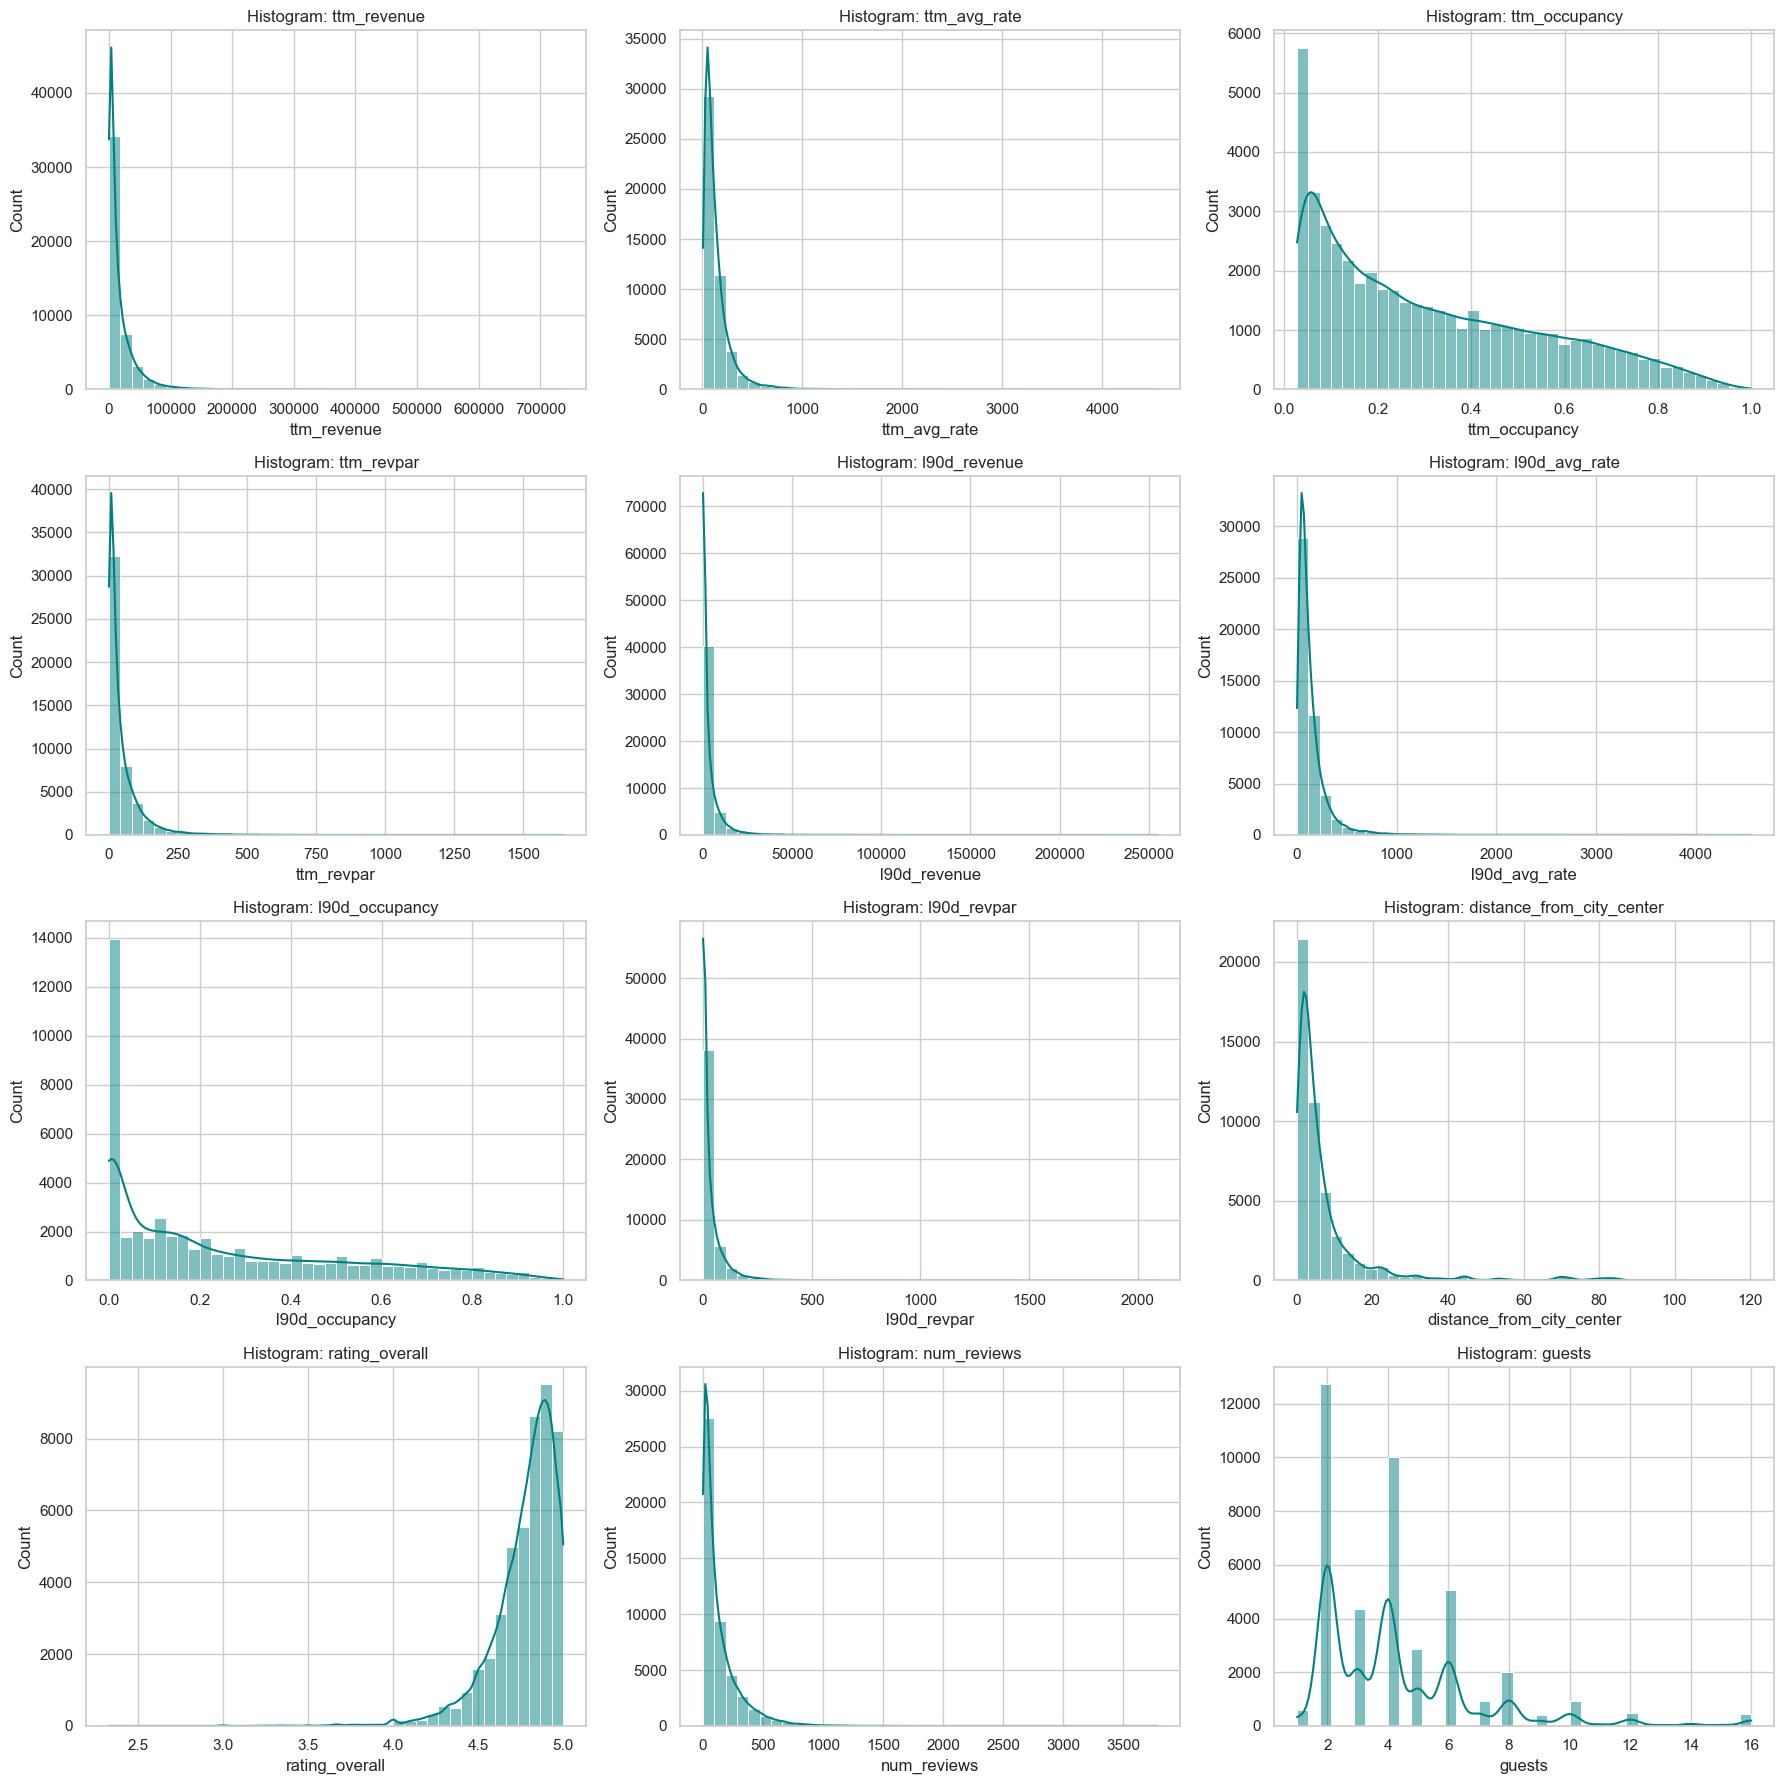

In [7]:
numeric_cols = df_plot.select_dtypes(include='number').columns.tolist()

priority_numeric = [
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'ttm_revpar',
    'l90d_revenue', 'l90d_avg_rate', 'l90d_occupancy', 'l90d_revpar',
    'distance_from_city_center', 'rating_overall', 'num_reviews',
    'guests', 'bedrooms', 'beds', 'baths'
]

hist_cols = [c for c in priority_numeric if c in numeric_cols]
if len(hist_cols) < 12:
    extras = [c for c in numeric_cols if c not in hist_cols]
    hist_cols.extend(extras[: 12 - len(hist_cols)])

hist_cols = hist_cols[:12]

n_cols = 3
n_rows = int(np.ceil(len(hist_cols) / n_cols)) if hist_cols else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, hist_cols):
    sns.histplot(df_plot[col].dropna(), bins=40, kde=True, ax=ax, color='teal')
    ax.set_title(f'Histogram: {col}')

for ax in axes[len(hist_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Correlation and Relationship Analysis

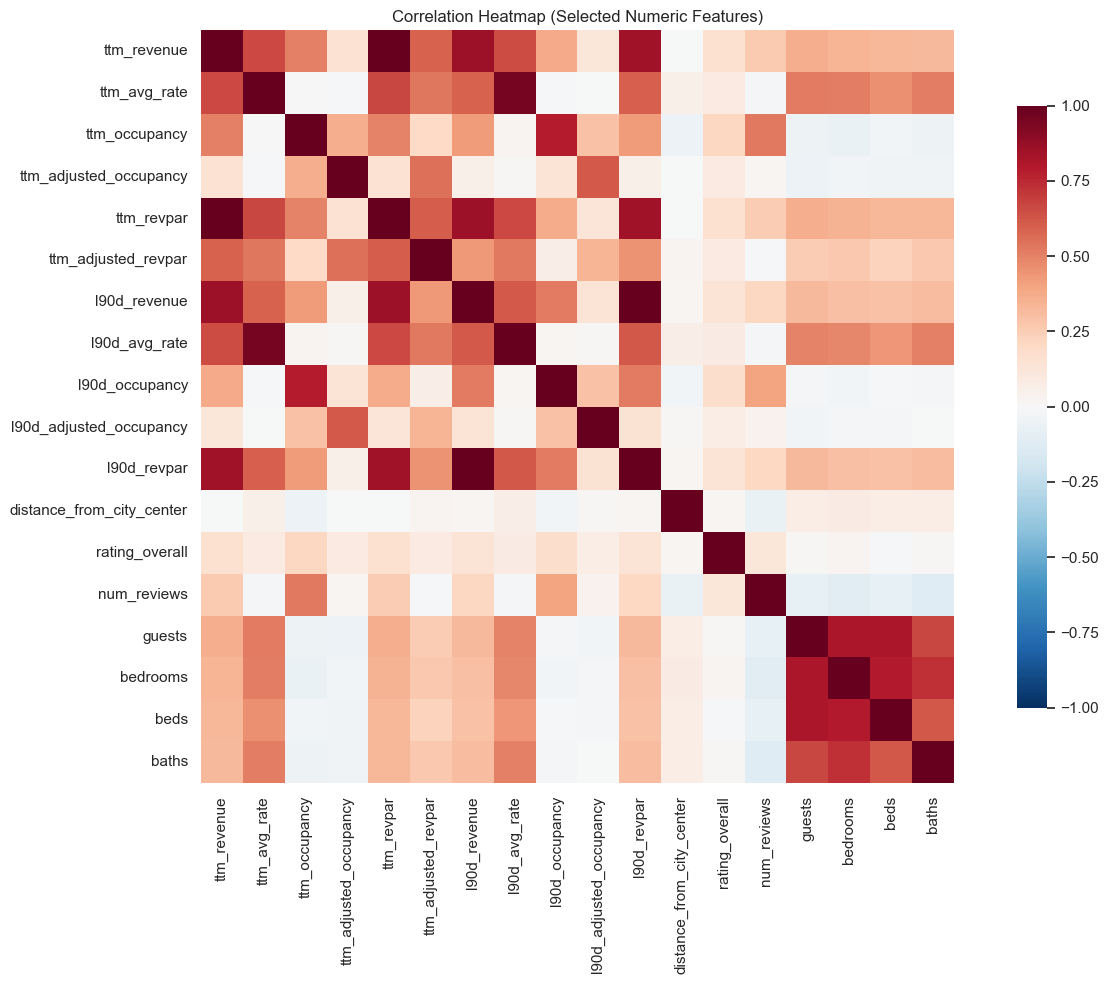

Top absolute correlations (excluding self-correlation):


,feature_1,feature_2,correlation
4,ttm_revenue,ttm_revpar,0.998009
118,l90d_revenue,l90d_revpar,0.997759
25,ttm_avg_rate,l90d_avg_rate,0.954963
6,ttm_revenue,l90d_revenue,0.856999
112,l90d_revenue,ttm_revpar,0.852972
180,l90d_revpar,ttm_revenue,0.851272
82,ttm_revpar,l90d_revpar,0.850987
268,guests,beds,0.814303
267,guests,bedrooms,0.813117
303,beds,bedrooms,0.794422


In [8]:
corr_priority = [
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'ttm_adjusted_occupancy',
    'ttm_revpar', 'ttm_adjusted_revpar', 'l90d_revenue', 'l90d_avg_rate',
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
    'distance_from_city_center', 'rating_overall', 'num_reviews',
    'guests', 'bedrooms', 'beds', 'baths'
]

corr_cols = [c for c in corr_priority if c in df_plot.columns and c in numeric_cols]

if len(corr_cols) >= 2:
    corr_matrix = df_plot[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr_matrix,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        annot=False,
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlation Heatmap (Selected Numeric Features)')
    plt.tight_layout()
    plt.show()

    corr_pairs = (
        corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
    )
    corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
    top_corr = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr']).head(12)

    print('Top absolute correlations (excluding self-correlation):')
    display(top_corr[['feature_1', 'feature_2', 'correlation']])
else:
    print('Not enough numeric columns available for correlation analysis.')

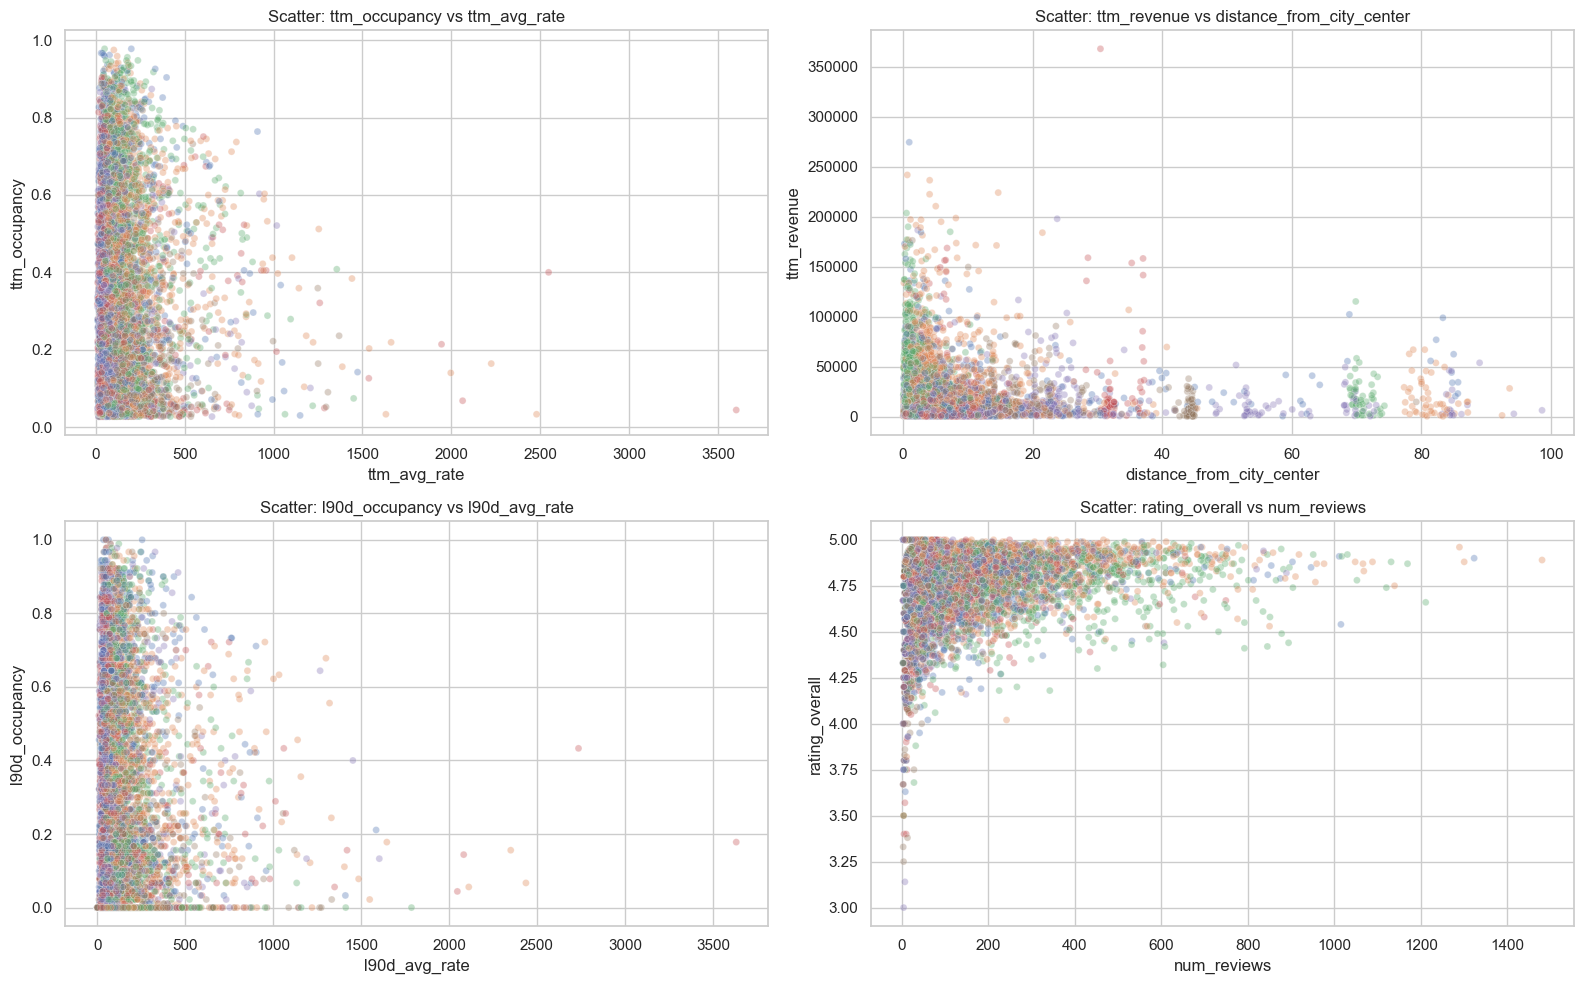

In [9]:
scatter_pairs = [
    ('ttm_avg_rate', 'ttm_occupancy'),
    ('distance_from_city_center', 'ttm_revenue'),
    ('l90d_avg_rate', 'l90d_occupancy'),
    ('num_reviews', 'rating_overall'),
]

available_pairs = [
    (x, y) for x, y in scatter_pairs
    if x in df_plot.columns and y in df_plot.columns
]

plot_df = df_plot.copy()
for x, y in available_pairs:
    plot_df = plot_df[plot_df[x].notna() & plot_df[y].notna()]

if len(plot_df) > 8000:
    plot_df = plot_df.sample(8000, random_state=RANDOM_STATE)

if available_pairs:
    n_cols = 2
    n_rows = int(np.ceil(len(available_pairs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    hue_col = 'geographic_zone' if 'geographic_zone' in plot_df.columns else None

    for ax, (x_col, y_col) in zip(axes, available_pairs):
        sns.scatterplot(
            data=plot_df,
            x=x_col,
            y=y_col,
            hue=hue_col,
            alpha=0.35,
            s=25,
            ax=ax,
            legend=False
        )
        ax.set_title(f'Scatter: {y_col} vs {x_col}')

    for ax in axes[len(available_pairs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No predefined scatterplot pairs found in current data.')

Columns with >= 40% missing values: 3


,missing_count,missing_pct
instant_book,41474,86.48
cohost_names,36904,76.95
cohost_ids,36904,76.95


Rows with all key performance metrics missing: 1 / 47,956


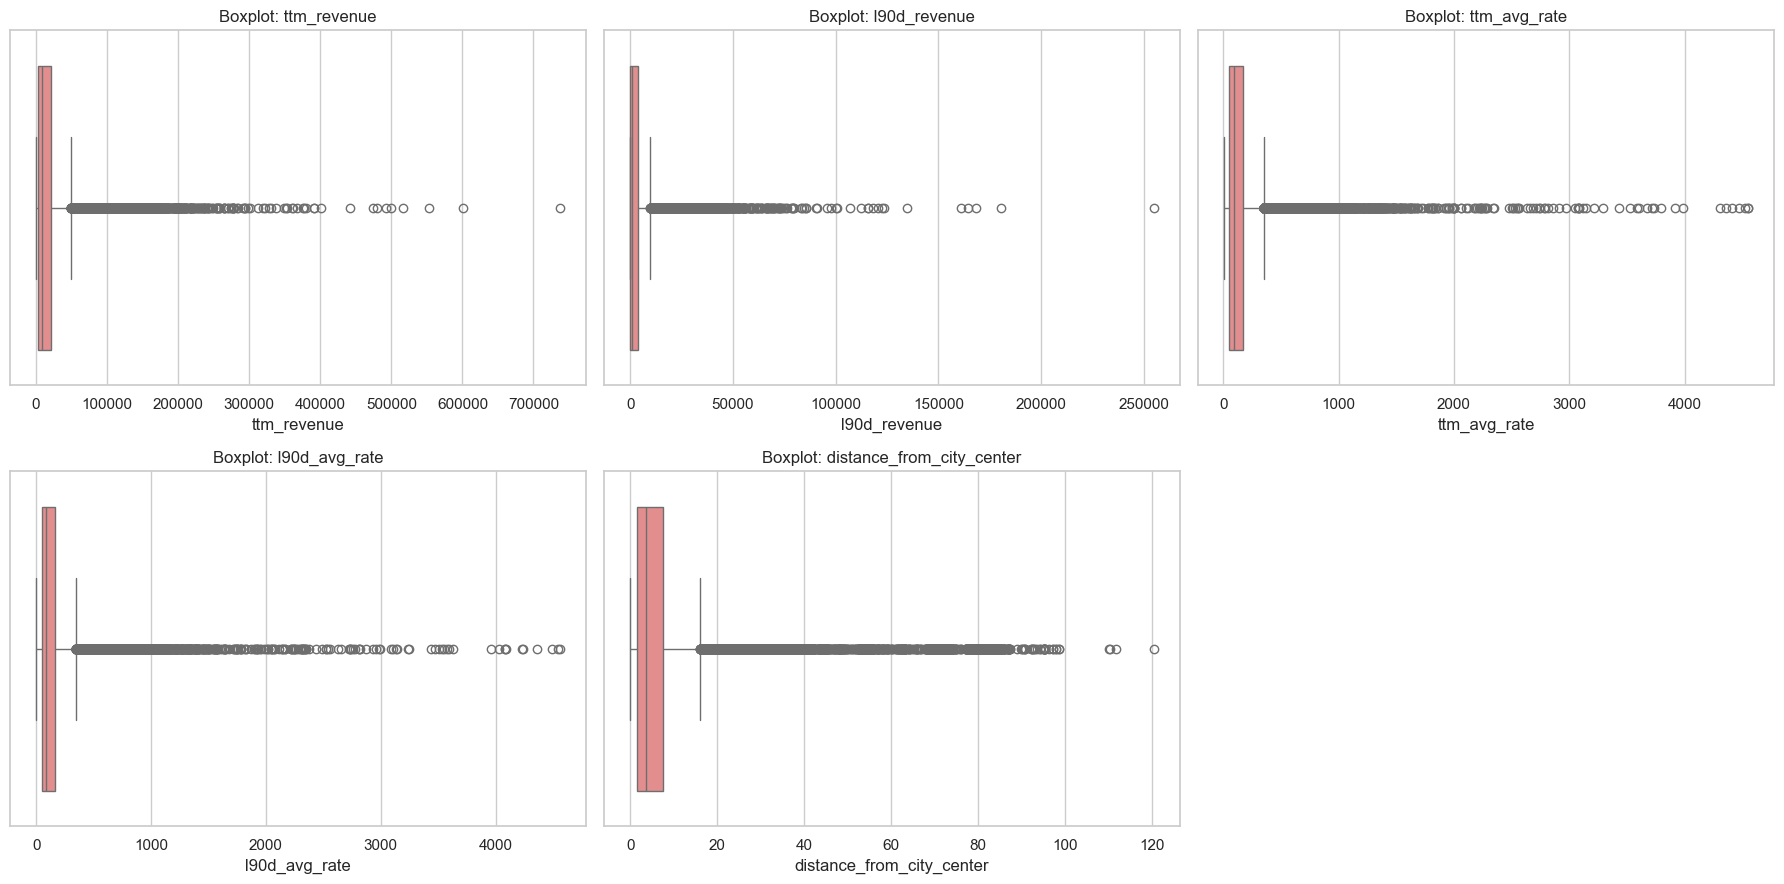


EDA completed. Use findings above to design the cleaning pipeline (type fixes, null treatment, and outlier handling).


In [10]:
high_missing = missing_summary[missing_summary['missing_pct'] >= 40]
print(f'Columns with >= 40% missing values: {len(high_missing)}')
if not high_missing.empty:
    display(high_missing.head(20))

# Potentially problematic rows: all key business metrics missing.
key_metrics = [
    c for c in ['ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'l90d_revenue', 'l90d_avg_rate', 'l90d_occupancy']
    if c in df_plot.columns
]

if key_metrics:
    all_key_missing = df_plot[key_metrics].isna().all(axis=1)
    print(f'Rows with all key performance metrics missing: {all_key_missing.sum():,} / {len(df_plot):,}')

# Quick outlier preview for selected business metrics.
outlier_cols = [c for c in ['ttm_revenue', 'l90d_revenue', 'ttm_avg_rate', 'l90d_avg_rate', 'distance_from_city_center'] if c in numeric_cols]
if outlier_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(outlier_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, outlier_cols):
        sns.boxplot(x=df_plot[col], ax=ax, color='lightcoral')
        ax.set_title(f'Boxplot: {col}')

    for ax in axes[len(outlier_cols):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('\nEDA completed. Use findings above to design the cleaning pipeline (type fixes, null treatment, and outlier handling).')